In [6]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
import glob as gb
import matplotlib.pyplot as plt

# Load the model
model = load_model('trash_classifier_baseModel.h5')
predpath = "pred"

# Get list of images in the specified path
images = gb.glob(pathname=predpath + '/*')
batch = []  # List to hold images for batch prediction

# Loop through each image and prepare batch
for img_path in images:
    img = image.load_img(img_path, target_size=(96, 96))  # Set target size according to your model input
    img_array = image.img_to_array(img)
    img_array = img_array / 127.5 - 1.0  # Normalize to [-1, 1]
    batch.append((img_path, img_array))  # Append the image and path to the batch



In [7]:
# Convert the batch to a numpy array
batch_array = np.array([img[1] for img in batch])  # Only get the image arrays
# Make predictions on the entire batch
preds = model.predict(batch_array)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 892ms/step


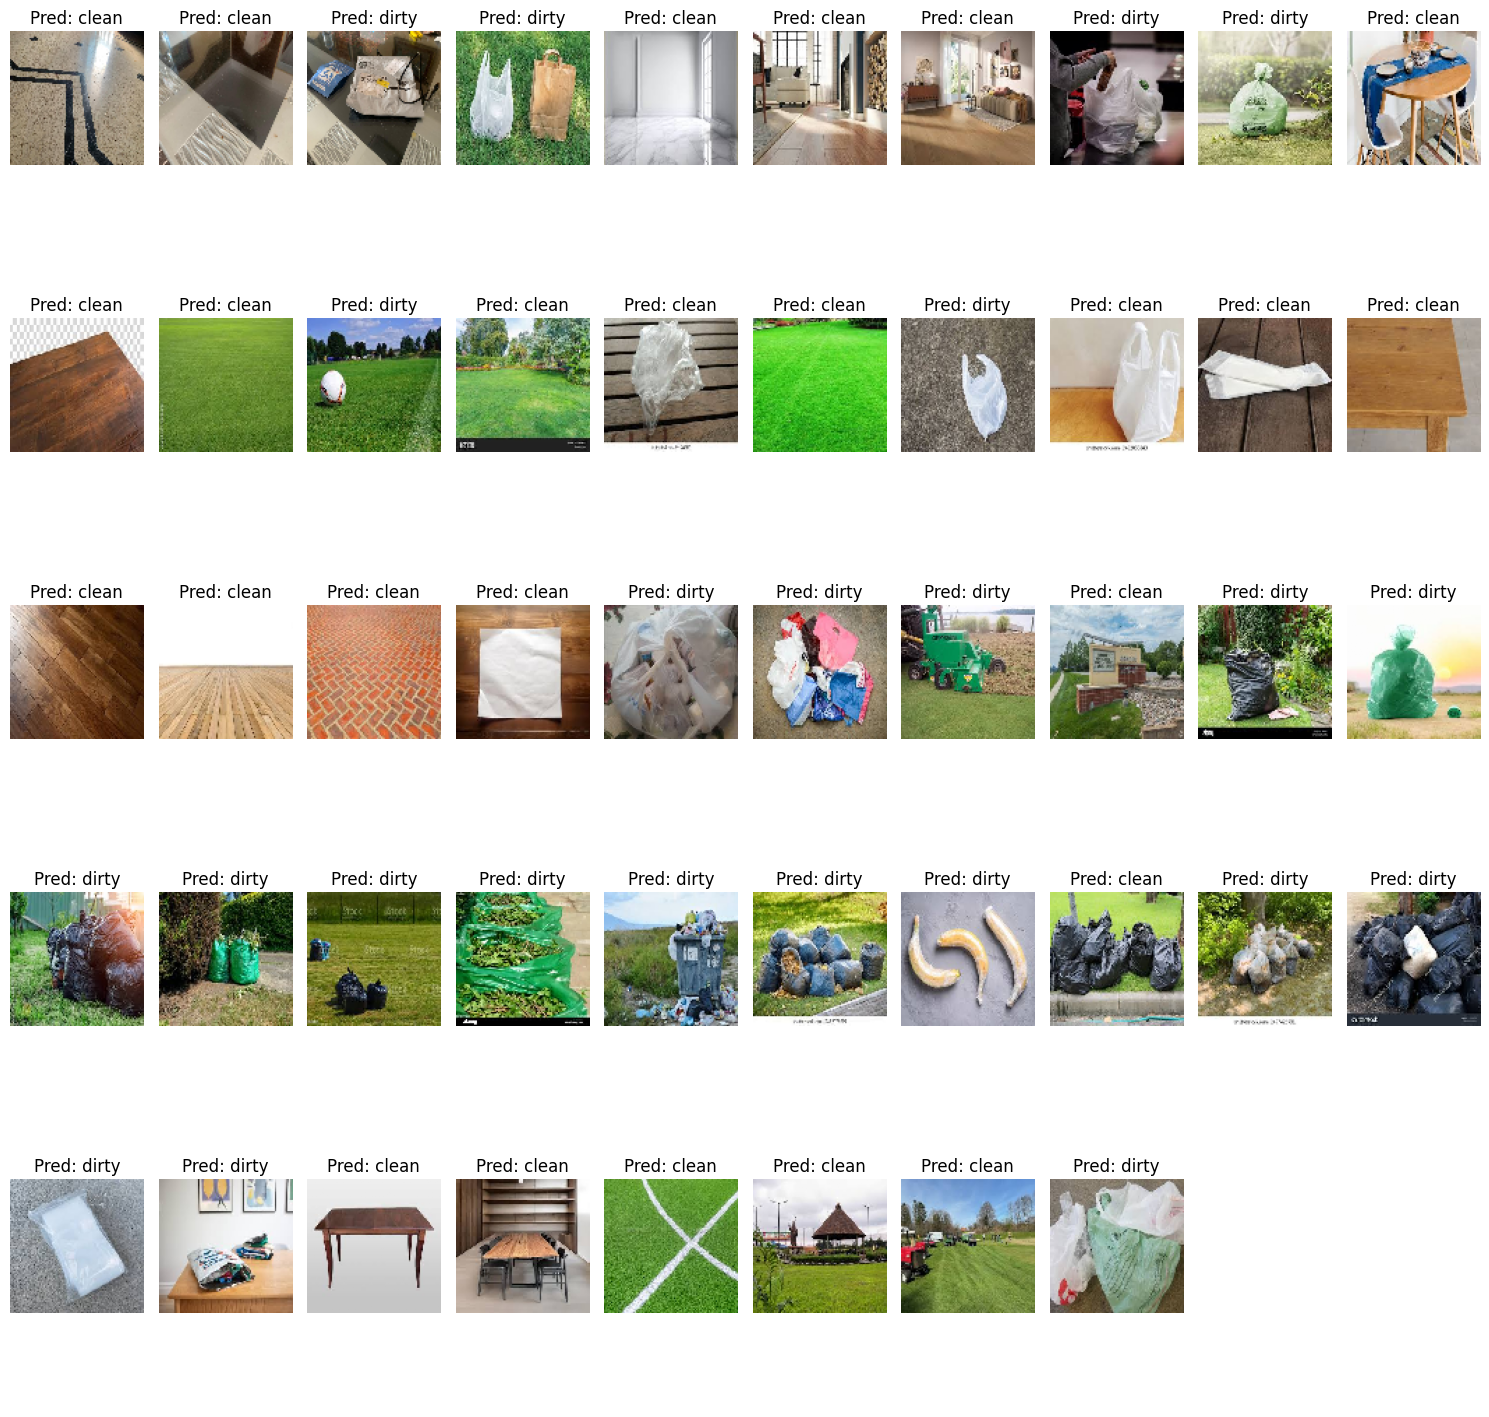

In [8]:
# Create a plot to display the images and predictions
num_images = len(images)
num_cols = min(num_images, 10)  # Set a max number of columns for better layout
num_rows = (num_images + num_cols - 1) // num_cols  # Calculate number of rows needed

# Create a figure for the plot
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3))

# Flatten the axes array for easier iteration
axes = axes.flatten() if num_rows > 1 else [axes]

# Loop through the images and predictions to display them
for ax, (img_path, img_array), prediction in zip(axes, batch, preds):
    # Show image
    ax.imshow((img_array + 1) / 2)  # Convert back to [0, 1] for displaying
    ax.axis('off')  # Hide axes

    # Determine predicted class
    predicted_class = (prediction[0] > 0.5).astype("int32")  # Adjust threshold as needed
    label = "clean" if predicted_class == 0 else "dirty"

    # Set title with prediction
    ax.set_title(f"Pred: {label}")

# Hide any unused axes
for i in range(len(batch), len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()